In [1]:
#--------------------------------------------------------------------------------------------------------
#Script to plot MZR plots across cosmic time in COLIBRE simulations
#Reproduces all the plots in Sharda, Schaye et al. 2026
#Author: Piyush Sharda (2026, Leiden University)
#Last updated: June 17, 2026
#--------------------------------------------------------------------------------------------------------

import os
import numpy as np
import h5py
import time
import cmasher as cm
import string
from pylab import genfromtxt
from pathlib import Path
import unyt
import pandas as pd
import h5py

import scipy.integrate as integrate
from scipy.optimize import curve_fit, root_scalar
from scipy.stats import gaussian_kde

import astropy.constants as cons
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from astropy.io import fits

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import LogNorm, LinearSegmentedColormap, to_rgba
import matplotlib.ticker as mtickerbrms
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#import all observations and some other functions
from my_funcs import *

COLIBRE_COLORS = [
    ('m5', '#C4E8FF'),
    ('m6', '#FF9F6E'),
    ('m7', '#D12424'),
]
PATH_EFFECTS = [pe.Stroke(linewidth=5, foreground="k"), pe.Normal()]
LINE_WIDTH = 3.5

defcolcycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

cosmo = FlatLambdaCDM(H0=68.1, Om0=0.306) #same parameters as Chaikin+25b (adopted by COLIBRE from Abbott et al. 2022)
masslimit_m5 = 2.3e5
masslimit_m6 = 1.84e6
masslimit_m7 = 1.47e7

masslimits = {"m5": masslimit_m5, "m6": masslimit_m6, "m7": masslimit_m7}
bbox = dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor='black',alpha=0.9)

#path where simulated data needed for all the plots is stored
simpath = 'simulated_data/'

#basic helper functions for tickmarks and colorbars
def set_allticks(ax,fontsize=14,color='k'):
    ax.tick_params(axis='both', which='major', direction = 'in', top=True, right=True, labelsize=fontsize, length=7, color=color)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction = 'in', top=True, right=True, labelsize=fontsize, length=4, color=color)
    return None

def set_cbar(image,axis,cbar_label,fontsize=12,labelpad=0):
    #sets all the properties of the colorbar for any figure
    divider = make_axes_locatable(axis)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cb=f.colorbar(image, cax=cax, orientation='vertical')
    cb.set_label(cbar_label, fontsize=fontsize, labelpad=labelpad)
    cb.ax.tick_params(which='major',direction='in',labelsize=fontsize,length=5)
    cb.ax.tick_params(which='minor',direction='in',labelsize=fontsize,length=3)
    return None


/Applications/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Finished in 0.12 s


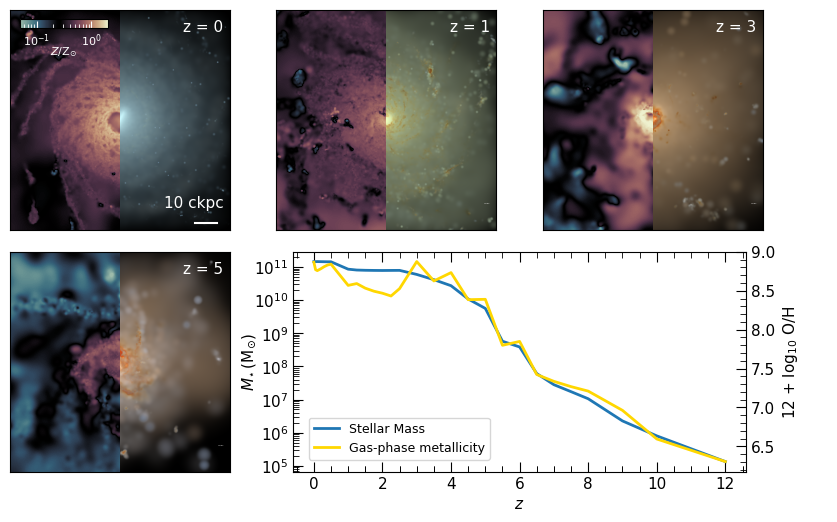

In [2]:
#Figure 1 of Sharda et al. 2026
_tstart = time.time()

f = plt.figure(figsize=(10, 6), constrained_layout=False)
gs = f.add_gridspec(2, 3, wspace=0.1, hspace=0.1, height_ratios=[1.00, 1.])
ax = np.empty((2, 3), dtype=object)
ax[0,0] = f.add_subplot(gs[0,0])
ax[0,1] = f.add_subplot(gs[0,1])
ax[0,2] = f.add_subplot(gs[0,2])
ax[1,0] = f.add_subplot(gs[1,0])
ax[1,1] = f.add_subplot(gs[1,1:3])

# remove the original wide axis
ax[1,1].remove()
# create a smaller one in the same grid cell
parent = f.add_subplot(gs[1,1:3])
ax[1,1] = inset_axes(parent, width="89%", height="100%", loc='center')
# optionally turn off the parent axis
parent.set_axis_off()


fontsize = 11

snaps = ['0127', '0092', '0064', '0048']
zz = [0, 1, 3, 5]
track_id = 918

lw = 2
lower, upper = 0.1, 1
n_colors = 100
new_colors = cm.copper_s_r(np.linspace(lower, upper, n_colors))
cmap_z = LinearSegmentedColormap.from_list('cropped_copper_s_r', new_colors)

vmin_z, vmax_z = 0.05, 2
vmin_m, vmax_m = 1e-2, 1e5
obsv = 'jwst'
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    # ---------------- METALLICITY ----------------
    bb = np.load(simpath+
                 f'projection_metallicity_{snap}_excl_50kpc_comoving_trackId_{str(track_id).zfill(8)}.npy').T

    im_z = ax[i, j].imshow(bb[:, 0:250] / 0.0134, origin='lower', norm=LogNorm(vmin=vmin_z, vmax=vmax_z), cmap=cmap_z,
                           extent=[0, 250, 0, 500])

    # ---------------- STELLAR LIGHT ----------------
    cc = np.load(simpath+
                 f'partridge_50kpc_comoving_snap_{snap}_trackID_{str(track_id).zfill(3)}_{obsv}.npy')

    im_m = ax[i, j].imshow(cc[:, 250:], extent=[250, 500, 0, 500])

    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])
    ax[i, j].text(0.97, 0.92, f'z = {zz[idx]}', ha='right', va='center', fontsize=fontsize, 
                  transform=ax[i, j].transAxes, color='white')
    ax[i, j].set_xticklabels([])
    ax[i, j].set_yticklabels([])

    if i==0 and j==0:
        ax[i, j].plot([420, 420+51.2], [15, 15], c='white')
        ax[i, j].text(0.97, 0.12, '10 ckpc', ha='right', va='center', fontsize=fontsize, 
                      transform=ax[i, j].transAxes, color='white')
    else:
        ax[i, j].plot([420, 420+51.2], [15, 15], c='k', ls='None')
        ax[i, j].text(0.97, 0.12, '10 ckpc', ha='right', va='center', fontsize=0, 
                      transform=ax[i, j].transAxes, color='white')

bb=pd.read_csv(simpath+'colibre_l025m5_trackID_918_fig1.csv')

ax[1,1].plot(bb['z'], bb['Mstar'], label='Stellar Mass',lw=2)
ax2 = ax[1,1].twinx()
ax2.plot(bb['z'], bb['12+log(O/H)'], c='gold',label='Gas-phase metallicity',lw=2)
ax[1,1].set_yscale('log')
ax[1,1].legend(loc='lower left',fontsize=fontsize-2,bbox_to_anchor=(0.02,0.025))
ax[1,1].set_xlabel(r'$z$', fontsize=fontsize)
ax[1,1].set_ylabel(r'$M_{\star}\,(\rm{M_{\odot}})$', fontsize=fontsize,labelpad=-3)
ax2.set_ylabel(r'12 + $\log_{10}\,\rm{O/H}$', fontsize=fontsize)

cax = f.add_axes([ax[0,0].get_position().x0 + 0.01,
                  ax[0,0].get_position().y1 - 0.03,
                  ax[0,0].get_position().width * 0.4,
                  0.015])

cb = plt.colorbar(im_z, cax=cax, orientation='horizontal')
cb.set_label(r'$Z/\rm{Z_{\odot}}$', fontsize=8, color='white',labelpad=-3)
cb.ax.tick_params(which='major',direction='in',labelsize=8,length=5,colors='white')
cb.ax.tick_params(which='minor',direction='in',labelsize=8,length=3,color='white')

color='k'
ax[1,1].tick_params(axis='both', which='major', direction = 'in', top=True, right=False, labelsize=fontsize, length=7, color=color)
ax[1,1].minorticks_on()
ax[1,1].tick_params(axis='both', which='minor', direction = 'in', top=True, right=False, labelsize=fontsize, length=4, color=color)

ax2.tick_params(axis='both', which='major', direction = 'in', top=False, right=True, left=False, labelsize=fontsize, length=7, color=color)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='minor', direction = 'in', top=False, right=True, left=False, labelsize=fontsize, length=4, color=color)

#f.savefig('Figure1.png', bbox_inches='tight', dpi=300)
print(f"Finished in {time.time() - _tstart:.2f} s")


Cell took 0.06 s


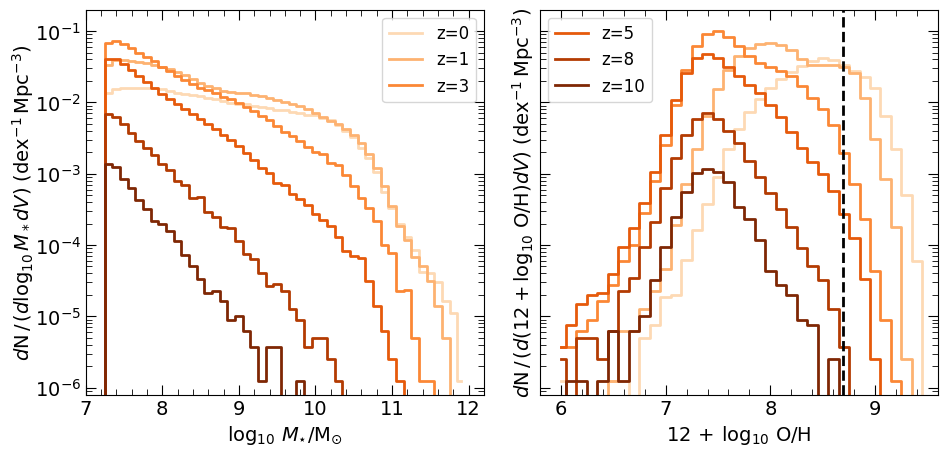

In [3]:
#Figure 2

_tstart = time.time()
f, ax = plt.subplots(1,2, figsize=(11, 5),gridspec_kw = {'hspace':0., 'wspace':0.14})
fontsize=14
min_count=20
reslimit_count=10

cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.2, 1, 6))

zz = [0, 1, 3, 5, 8, 10]
lw=2


bb=np.load(simpath+'figure2_data.npz', allow_pickle=True)


for idx in range(0, len(zz)):
    if zz[idx]<=3:
        ax[0].step(bb['bin_centers0'][idx], bb['phi0'][idx], where='mid', color=colorss[idx], lw=lw, 
                   label=r'z=%d' % zz[idx])
    else:
        ax[0].step(bb['bin_centers0'][idx], bb['phi0'][idx], where='mid', color=colorss[idx], lw=lw)
    
    if zz[idx] > 3:
        ax[1].step(bb['bin_centers1'][idx], bb['phi1'][idx], where='mid', color=colorss[idx], lw=lw, 
                   label=r'z=%d' % zz[idx])
    else:
        ax[1].step(bb['bin_centers1'][idx], bb['phi1'][idx], where='mid', color=colorss[idx], lw=lw)

ax[1].axvline(x=8.69, c='k', lw=lw, ls='dashed')
set_allticks(ax[0], fontsize=fontsize)
set_allticks(ax[1], fontsize=fontsize)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(8e-7, 2e-1)
ax[1].set_ylim(8e-7, 2e-1)
ax[0].set_xlim(7, 12.2)
ax[1].set_xlim(5.8, 9.6)
ax[0].legend(fontsize=fontsize-2, loc='upper right', ncol=1)
ax[1].legend(fontsize=fontsize-2, loc='upper left', ncol=1)
ax[1].set_yticklabels([])
ax[0].set_ylabel(r'$d\mathrm{N}\,/\,\left(d\log_{10}M_* dV\right)$ ($\rm{dex^{-1}\,Mpc^{-3}}$)', fontsize=fontsize, labelpad=-1)
ax[1].set_ylabel(r'$d\mathrm{N}\,/\,\left(d(12+\log_{10}\,\mathrm{O/H}) dV\right)$ ($\rm{dex^{-1}\,Mpc^{-3}}$)', fontsize=fontsize, labelpad=-1)
ax[0].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
ax[1].set_xlabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)

#f.savefig('Figure2.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 2.79 s


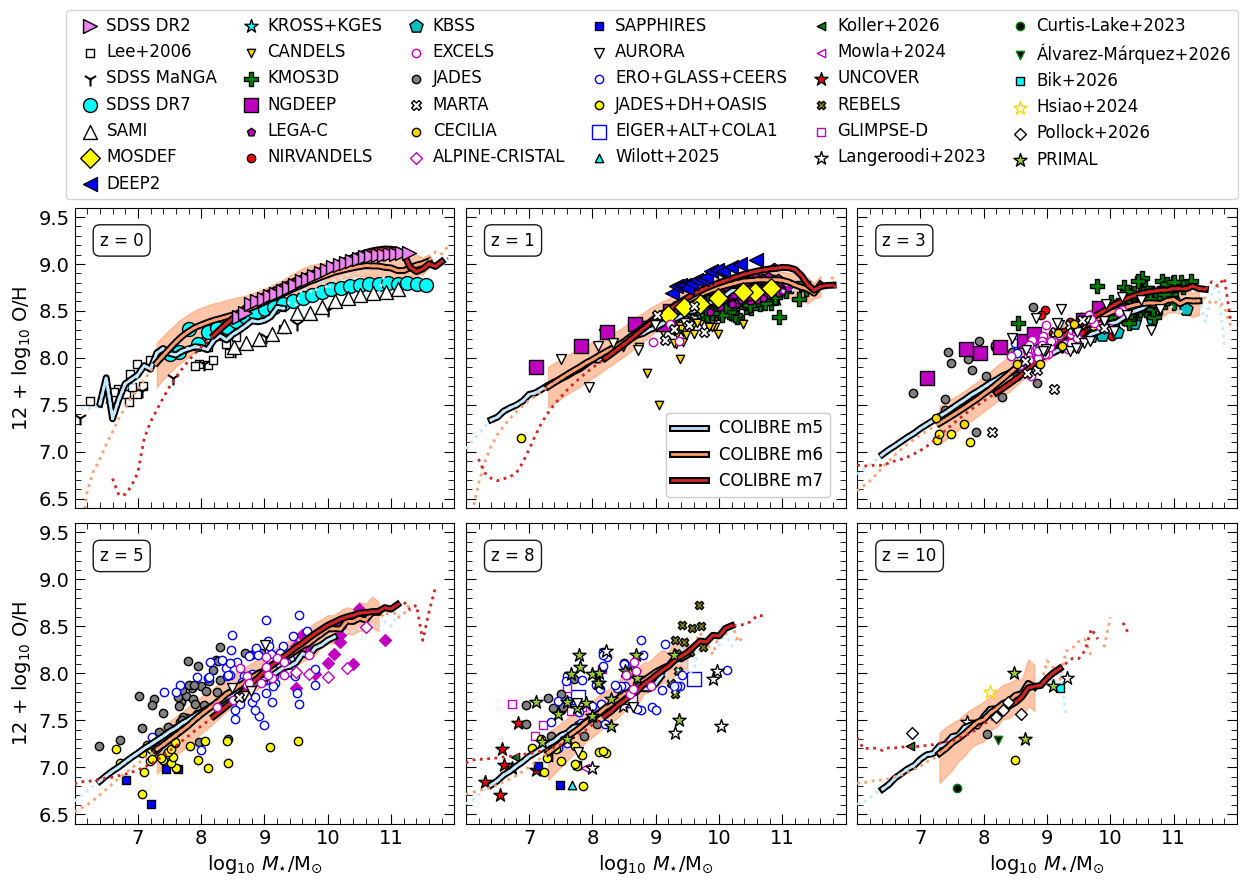

In [9]:
#Figure 3

_tstart = time.time()
f, ax = plt.subplots(2,3, figsize=(15, 8), gridspec_kw = {'wspace':0.03, 'hspace':0.05})
fontsize=14
min_count = 20 #need minimum "min_count" galaxies per bin
reslimit_count = 10 #need minimum "reslimit_count" star particles in a galaxy


plot_obsv_data(ax, zorder=3)

snaps = ['0127', '0092', '0064', '0048', '0026', '0018']
zz = [0, 1, 3, 5, 8, 10]
lw=2
handletextpad=0.01
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    model='m5'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], path_effects=PATH_EFFECTS, zorder=4)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], ls='dotted', zorder=4)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], ls='dotted', zorder=4)

    model='m6'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], path_effects=PATH_EFFECTS, zorder=4)
    #plot 16/84 percentile scatter
    ax[i][j].fill_between(bb['bin_centers'][mask], bb['p16'][mask], bb['p84'][mask], color=COLIBRE_COLORS[1][1], alpha=0.6, zorder=1)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], ls='dotted', zorder=4)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], ls='dotted', zorder=4)

    model='m7'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], path_effects=PATH_EFFECTS, zorder=4)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], ls='dotted', zorder=4)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], ls='dotted', zorder=4)

    set_allticks(ax[i][j], fontsize=fontsize)
    ax[i][j].set_xticks([7, 8, 9, 10, 11])
    ax[i][j].set_ylim(6.4, 9.6)
    ax[i][j].set_xlim(6, 12)
    ax[i][j].text(6.4, 9.25, 'z = %d'%zz[idx], ha='left', va='center', fontsize=fontsize-2, bbox=bbox)
    if i==1:
        ax[i][j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    else:
        ax[i][j].set_xticklabels([])
    if j==0:
        ax[i][j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[i][j].set_yticklabels([])

ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=COLIBRE_COLORS[0][1],path_effects=PATH_EFFECTS)
ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=COLIBRE_COLORS[1][1],path_effects=PATH_EFFECTS)
ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=COLIBRE_COLORS[2][1],path_effects=PATH_EFFECTS)
lines=ax[0][1].get_lines()
aa=len(lines)-1
legend2 = ax[0][1].legend([lines[i] for i in [aa-2, aa-1, aa]], [r'COLIBRE '+COLIBRE_COLORS[0][0], 
                                                                   r'COLIBRE '+COLIBRE_COLORS[1][0], 
                                                                   r'COLIBRE '+COLIBRE_COLORS[2][0]], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.98, 0.01))
ax[0][1].add_artist(legend2)



# COMBINED LEGEND
handles_all = []
labels_all = []

for axi in ax.flat:

    h, l = axi.get_legend_handles_labels()

    handles_all.extend(h)
    labels_all.extend(l)

# Remove duplicates while preserving order
unique = {}

for h, l in zip(handles_all, labels_all):

    # Skip COLIBRE legend entries
    if 'COLIBRE' in l:
        continue

    if l not in unique:
        unique[l] = h

fig_legend = f.legend(unique.values(), unique.keys(), loc='lower center', bbox_to_anchor=(0.51, 0.88),
                      ncol=6, fontsize=fontsize-2, frameon=True, handletextpad=0.01, columnspacing=1.0)


#f.savefig('Figure3.pdf', bbox_inches='tight')
f.savefig('../colibre/plot_mzr.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 0.31 s


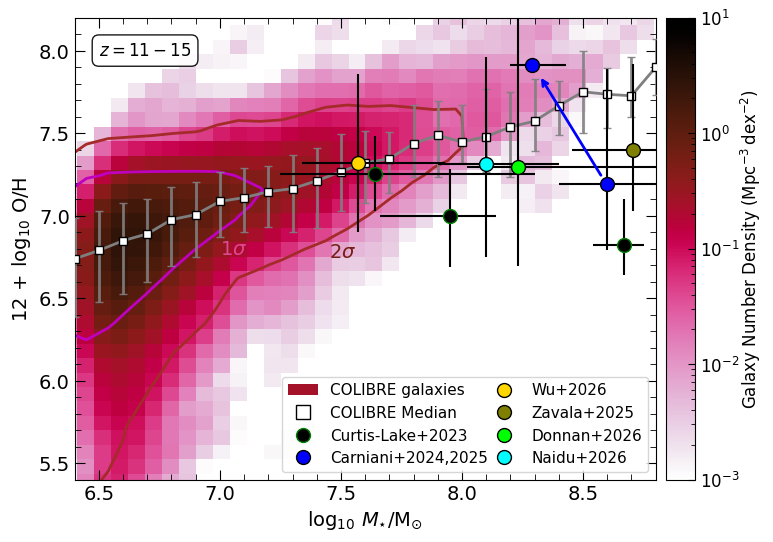

In [30]:
#Figure 4

_tstart = time.time()

reslimit_count = 10

f, ax = plt.subplots(1,1,figsize=(8,6))
fontsize=14

min_count = 20
reslimit_count = 10

# evaluate on a regular grid
xgrid = np.linspace(6, 9.5, 40)
ygrid = np.linspace(5, 8.5, 40)
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)

bb = np.load(simpath+'contours_data.npz', allow_pickle=True)
Z = bb['Z']
x_all = bb['x_all']
y_all = bb['y_all']

im=ax.imshow(Z.reshape(Xgrid.shape), origin='lower', aspect='auto', extent=[6.2, 9., 5, 8.5], 
             cmap=cm.flamingo_r, label=r'COLIBRE galaxies', norm=LogNorm(vmin=1e-3, vmax=1e1))
set_cbar(im,ax,r'Galaxy Number Density $(\rm{Mpc^{-3}\,dex^{-2}})$')
set_allticks(ax)
bbox = dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor='black',alpha=0.9)
ax.text(6.5, 8, r'$z = 11 - 15$', ha='left', va='center', fontsize=fontsize-2, bbox=bbox)

cmap = cm.flamingo_r
colorss = cmap(np.linspace(0.4, 0.7, 2))
# Normalize to PDF
Z = Z / Z.sum()
# Flatten and sort (highest density first)
Zflat = Z.ravel()
idx = np.argsort(Zflat)[::-1]
Zsorted = Zflat[idx]
cumsum = np.cumsum(Zsorted)

# 1σ = 68% enclosed probability (2D)
level_1sigma = Zsorted[np.searchsorted(cumsum, 0.6827)]
ax.contour(Xgrid, Ygrid, Z.reshape(Xgrid.shape), levels=[level_1sigma],colors='m',linewidths=2)
ax.text(7.0, 6.80, r'$1\sigma$', fontsize=fontsize, ha='left', va='center', color=colorss[0])
# 2σ = 95% enclosed probability (2D)
level_2sigma = Zsorted[np.searchsorted(cumsum, 0.9545)]
ax.contour(Xgrid, Ygrid, Z.reshape(Xgrid.shape), levels=[level_2sigma],colors='brown',linewidths=2)
ax.text(7.45, 6.78, r'$2\sigma$', fontsize=fontsize, ha='left', va='center', color=colorss[1])

ax.set_xlim(6.4, 8.8)
ax.set_ylim(5.4, 8.2)
ax.set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
ax.set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)

#z>=11 galaxies from Curtis-Lake+2023, Table 1
ax.errorbar([8.67, 7.64, 7.95], [8.69-1.87, 8.69-1.44, 8.69-1.69], xerr=[[0.13, 0.39, 0.29],[0.08, 0.66, 0.19]], yerr=[[0.18, 0.22, 0.31],[0.28, 0.23, 0.28]],
            fmt='o', mfc='k', mec='green', ecolor='k', label='Curtis-Lake+2023', zorder=5, ms=10)
#GS-z14-0 galaxy from Carniani+2024, Table 1 (for the second source GS-z14-1 in Carniani+, we use updated values from Wu below)
ax.errorbar([8.6], [8.69-1.5], xerr=[[0.2],[0.7]], yerr=[[0.4],[0.7]],
            fmt='o', mfc='blue', mec='k', ecolor='k', label='Carniani+2024', zorder=5, ms=10)
#we also use updated value from Carniani+2025 for the same galaxy, to show how updated measurements move the value around
ax.errorbar([8.29], [8.69-0.78], xerr=[[0.09],[0.14]], yerr=[[0.03],[0.03]],
            fmt='o', mfc='blue', mec='k', ecolor='k', label='Carniani+2025', zorder=5, ms=10)
#GS-z14-1 galaxy from Wu, Z, Einsenstein+2026 (this source is also in Carniani, but we use the more updated values)
ax.errorbar([7.57], [8.69-1.37], xerr=[[0.23],[0.36]], yerr=[[0.42],[0.54]],
            fmt='o', mfc='gold', mec='k', ecolor='k', label='Wu+2026', zorder=5, ms=10)
#GHZ-2 galaxy from Zavala+2025
ax.errorbar([8.705], [7.40], xerr=[[0.25],[0.15]], yerr=[[0.37],[0.52]],
            fmt='o', mfc='olive', mec='k', ecolor='k', label='Zavala+2025', zorder=5, ms=10)
#PAN-z14-1 galaxy from Donnan+2026
ax.errorbar([8.23], [8.69+np.log10(0.04)], xerr=[[0.21],[1.14]], yerr=[[0.60],[1.21]],
            fmt='o', mfc='lime', mec='k', ecolor='k', label='Donnan+2026', zorder=5, ms=10)
#MoM-z14 galaxy from Naidu+2026
ax.errorbar([8.1], [8.69-1.38], xerr=[[0.2],[0.3]], yerr=[[0.56],[0.65]],
            fmt='o', mfc='cyan', mec='k', ecolor='k', label='Naidu+2026', zorder=5, ms=10)

ax.annotate('',  xy=(8.29+0.03, 8.69-0.78-0.06), xytext=(8.6-0.02, 8.69-1.5+0.04), 
            arrowprops=dict(arrowstyle='->',color='blue',lw=2),zorder=6)

proxy = Patch(facecolor=cm.flamingo_r(0.6),label='COLIBRE galaxies')
proxy1 = Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='white', 
                markeredgecolor='k', markersize=10, label='COLIBRE Median')
proxy2 = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='k', 
                markeredgecolor='green', markersize=10, label='Curtis-Lake+2023')
proxy22 = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='blue', 
                markeredgecolor='k', markersize=10, label='Carniani+2024,2025')
proxy32 = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='gold', 
                markeredgecolor='k', markersize=10, label='Wu+2026')
proxy42 = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='olive', 
                markeredgecolor='k', markersize=10, label='Zavala+2025')
proxy41 = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='lime', 
                markeredgecolor='k', markersize=10, label='Donnan+2026')
proxy43 = Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='cyan', 
                markeredgecolor='k', markersize=10, label='Naidu+2026')

ax.legend(handles=[proxy, proxy1, proxy2, proxy22, proxy32, proxy42, proxy41, proxy43], loc='lower right', fontsize=fontsize-3, ncol=2, columnspacing=0)

bc, med, counts, p16, p84 = plot_median(x_all, y_all)
ax.errorbar(bc, med, yerr=[med-p16, p84-med], fmt='s-', markeredgecolor='k',mfc='white', capsize=3, 
            lw=2, zorder=4, ecolor=to_rgba('grey', alpha=0.9))

#f.savefig('Figure4.pdf', bbox_inches='tight')
f.savefig('../colibre/plot_contours.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")


Cell took 0.19 s


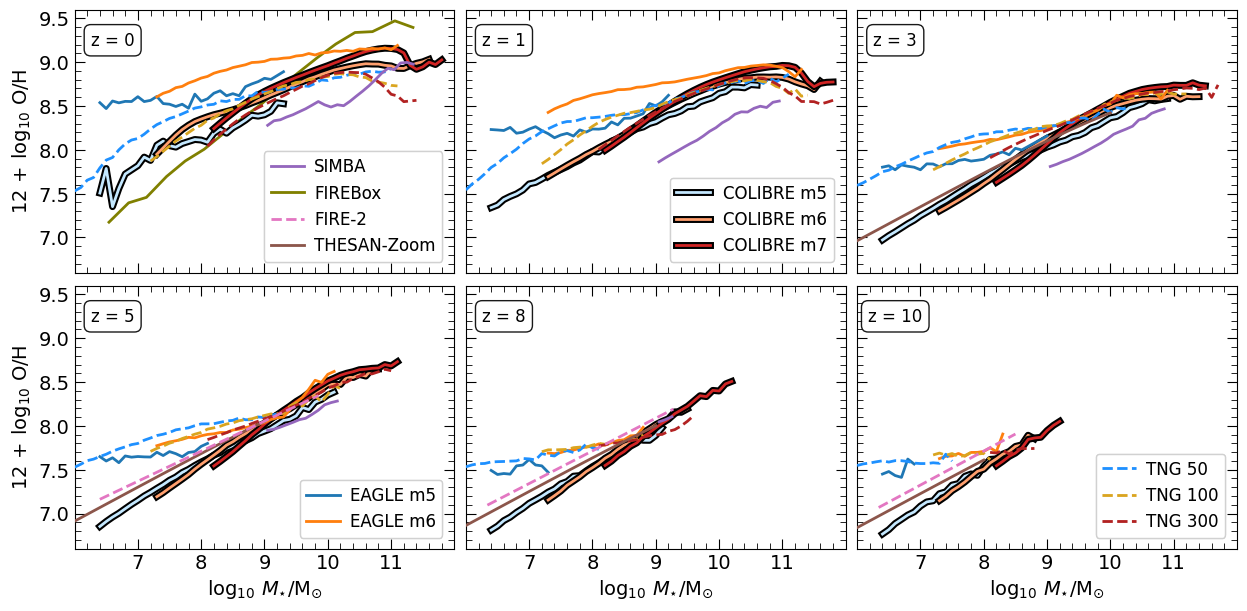

In [5]:
#Figure 5

_tstart = time.time()
f, ax = plt.subplots(2,3, figsize=(15, 7), gridspec_kw = {'wspace':0.03, 'hspace':0.05})
fontsize=14
min_count = 20
reslimit_count = 10


res = 'm5'
box = 'L025'
eagle_masslimit = {'m5':2.26e5, 'm6':1.81e6}
tng_masslimit = {'50':8.5e4, '100':1.4e6, '300':1.1e7}

zz = [0]
idx = 0
zorder = 4

snaps = ['0127', '0092', '0064', '0048', '0026', '0018']
zz = [0, 1, 3, 5, 8, 10]
lw=2
handletextpad=0.01
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    model='m5'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], path_effects=PATH_EFFECTS, zorder=4)

    model='m6'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], path_effects=PATH_EFFECTS, zorder=4)

    model='m7'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], path_effects=PATH_EFFECTS, zorder=4)

    #EAGLE
    res = 'm5'
    bb = np.load(simpath+f'plot_mzr_sims_data_eagle_{res}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * eagle_masslimit[res])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=defcolcycle[0], ls='solid', zorder=4)
    res = 'm6'
    bb = np.load(simpath+f'plot_mzr_sims_data_eagle_{res}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * eagle_masslimit[res])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=defcolcycle[1], ls='solid', zorder=4)
    
    
    #TNG
    res = '50'
    bb = np.load(simpath+f'plot_mzr_sims_data_tng_{res}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * tng_masslimit[res])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color='dodgerblue', ls='dashed', zorder=4)
    res = '100'
    bb = np.load(simpath+f'plot_mzr_sims_data_tng_{res}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * tng_masslimit[res])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color='goldenrod', ls='dashed', zorder=4)
    res = '300'
    bb = np.load(simpath+f'plot_mzr_sims_data_tng_{res}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * tng_masslimit[res])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color='firebrick', ls='dashed', zorder=4)

    set_allticks(ax[i][j], fontsize=fontsize)
    ax[i][j].set_xticks([7, 8, 9, 10, 11])
    ax[i][j].set_ylim(6.6, 9.6)
    ax[i][j].set_xlim(6, 12)
    ax[i][j].text(np.log10(4e6), 9.25, 'z = %d'%zz[idx], ha='center', va='center', fontsize=fontsize-2, bbox=bbox)
    if i==1:
        ax[i][j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    else:
        ax[i][j].set_xticklabels([])
    if j==0:
        ax[i][j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[i][j].set_yticklabels([])


ls='solid'
ax[0][0].plot(simba_0_mass, simba_0_metallicity, c=defcolcycle[4], lw=lw, ls=ls, zorder=zorder)
ax[0][1].plot(simba_1_mass, simba_1_metallicity, c=defcolcycle[4], lw=lw, ls=ls, zorder=zorder)
ax[0][2].plot(simba_3_mass, simba_3_metallicity, c=defcolcycle[4], lw=lw, ls=ls, zorder=zorder)
ax[1][0].plot(simba_5_mass, simba_5_metallicity, c=defcolcycle[4], lw=lw, ls=ls, zorder=zorder,label='SIMBA')
ax[1][1].plot(simba_8_mass, simba_8_metallicity, c=defcolcycle[4], lw=lw, ls=ls, zorder=zorder)

#THESAN-ZOOM project best-fit relation, valid between 3 < z < 12 in redshift bins of 0.5 dex, stellar mass from 1e6 to 1e11 in bins of 0.5 dex
th_Z0 = 8.98
th_alpha = 0.28
th_beta = 0.55
th_M0 = 10.74
th_gamma = 0.39
xx_list = [np.linspace(6, 10, 100), np.linspace(6, 9, 100), np.linspace(6, 9, 100), np.linspace(6, 8, 100)]
th_z = [3,5,8,10]
positions = [(0, 2), (1, 0), (1, 1), (1, 2)]
for z, (i, j), xx in zip(th_z, positions, xx_list):
    yy = th_Z0 - th_alpha*np.log10(1 + z) - (th_gamma/th_beta) * np.log10(1.0 + ((10**xx)/(10**th_M0))**-th_beta)
    ax[i][j].plot(xx, yy, ls='solid', zorder=zorder, c=defcolcycle[5], lw=lw)
    
#FIRE-2 relations
ls='dashed'
zz=[5,8,10]
#limit stellar mass range to where FIRE-2 has > 5 galaxies available (figure 1 of Marszewski+2024)
xx = [np.linspace(6.4, 9.85, 100), np.linspace(6.34, 9.278, 100), np.linspace(6.34, 8.50, 100)]
a=[0.343,0.373,0.388]
b=[-4.033,-4.269,-4.391]
for i in range(len(zz)):
    yy = 9.0 + a[i]*xx[i] + b[i]
    if i==0:
        ax[1][i].plot(xx[i], yy, ls=ls, lw=lw, zorder=zorder, c=defcolcycle[6],label=r'FIRE-2')
    else:
        ax[1][i].plot(xx[i], yy, ls=ls, lw=lw, zorder=zorder, c=defcolcycle[6])

#FIREbox z=0
bb=pd.read_csv(simpath+'FIREbox_z=0_mzr.csv')
ax[0][0].plot(bb['logM'], bb['OH'], ls='solid', lw=lw, c='olive',label='FIREBox')

lines=ax[0][1].get_lines()
legend2 = ax[0][1].legend([lines[i] for i in [0, 1, 2]], [r'COLIBRE '+COLIBRE_COLORS[0][0], 
                                                                   r'COLIBRE '+COLIBRE_COLORS[1][0], 
                                                                   r'COLIBRE '+COLIBRE_COLORS[2][0]], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.01))
ax[0][1].add_artist(legend2)

ax[0][0].plot(xx[i]*0, yy*0, ls=ls, lw=lw, c=defcolcycle[6])
ax[0][0].plot(xx[i]*0, yy*0, ls='solid', zorder=zorder, c=defcolcycle[5], lw=lw)
lines=ax[0][0].get_lines()
legend2 = ax[0][0].legend([lines[i] for i in [8, 9, 10, 11]], [r'SIMBA', r'FIREBox', r'FIRE-2', r'THESAN-Zoom'], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.01), handletextpad=0.6, columnspacing=0.8)
ax[0][0].add_artist(legend2)

lines=ax[1][0].get_lines()
legend2 = ax[1][0].legend([lines[i] for i in [3, 4]], [r'EAGLE m5', r'EAGLE m6'], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.01), handletextpad=0.6, columnspacing=0.8)
ax[1][0].add_artist(legend2)

lines=ax[1][2].get_lines()
legend2 = ax[1][2].legend([lines[i] for i in [5, 6, 7]], [r'TNG 50', r'TNG 100', r'TNG 300'], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.01), handletextpad=0.6, columnspacing=0.8)
ax[1][2].add_artist(legend2)

#f.savefig('Figure5.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



obsv data plotted


/var/folders/bs/0lfjs9594398dgv84kk08wlc0000gq/T/ipykernel_82853/1263662683.py:85: RuntimeWarning: Mean of empty slice
  mzr_mstar10.append(np.nanmean(vals))
/var/folders/bs/0lfjs9594398dgv84kk08wlc0000gq/T/ipykernel_82853/1263662683.py:129: RuntimeWarning: Mean of empty slice
  mzr_mstar10.append(np.nanmean(vals))
/var/folders/bs/0lfjs9594398dgv84kk08wlc0000gq/T/ipykernel_82853/1263662683.py:151: RuntimeWarning: Mean of empty slice
  mzr_mstar11.append(np.nanmean(vals))


Cell took 3.51 s


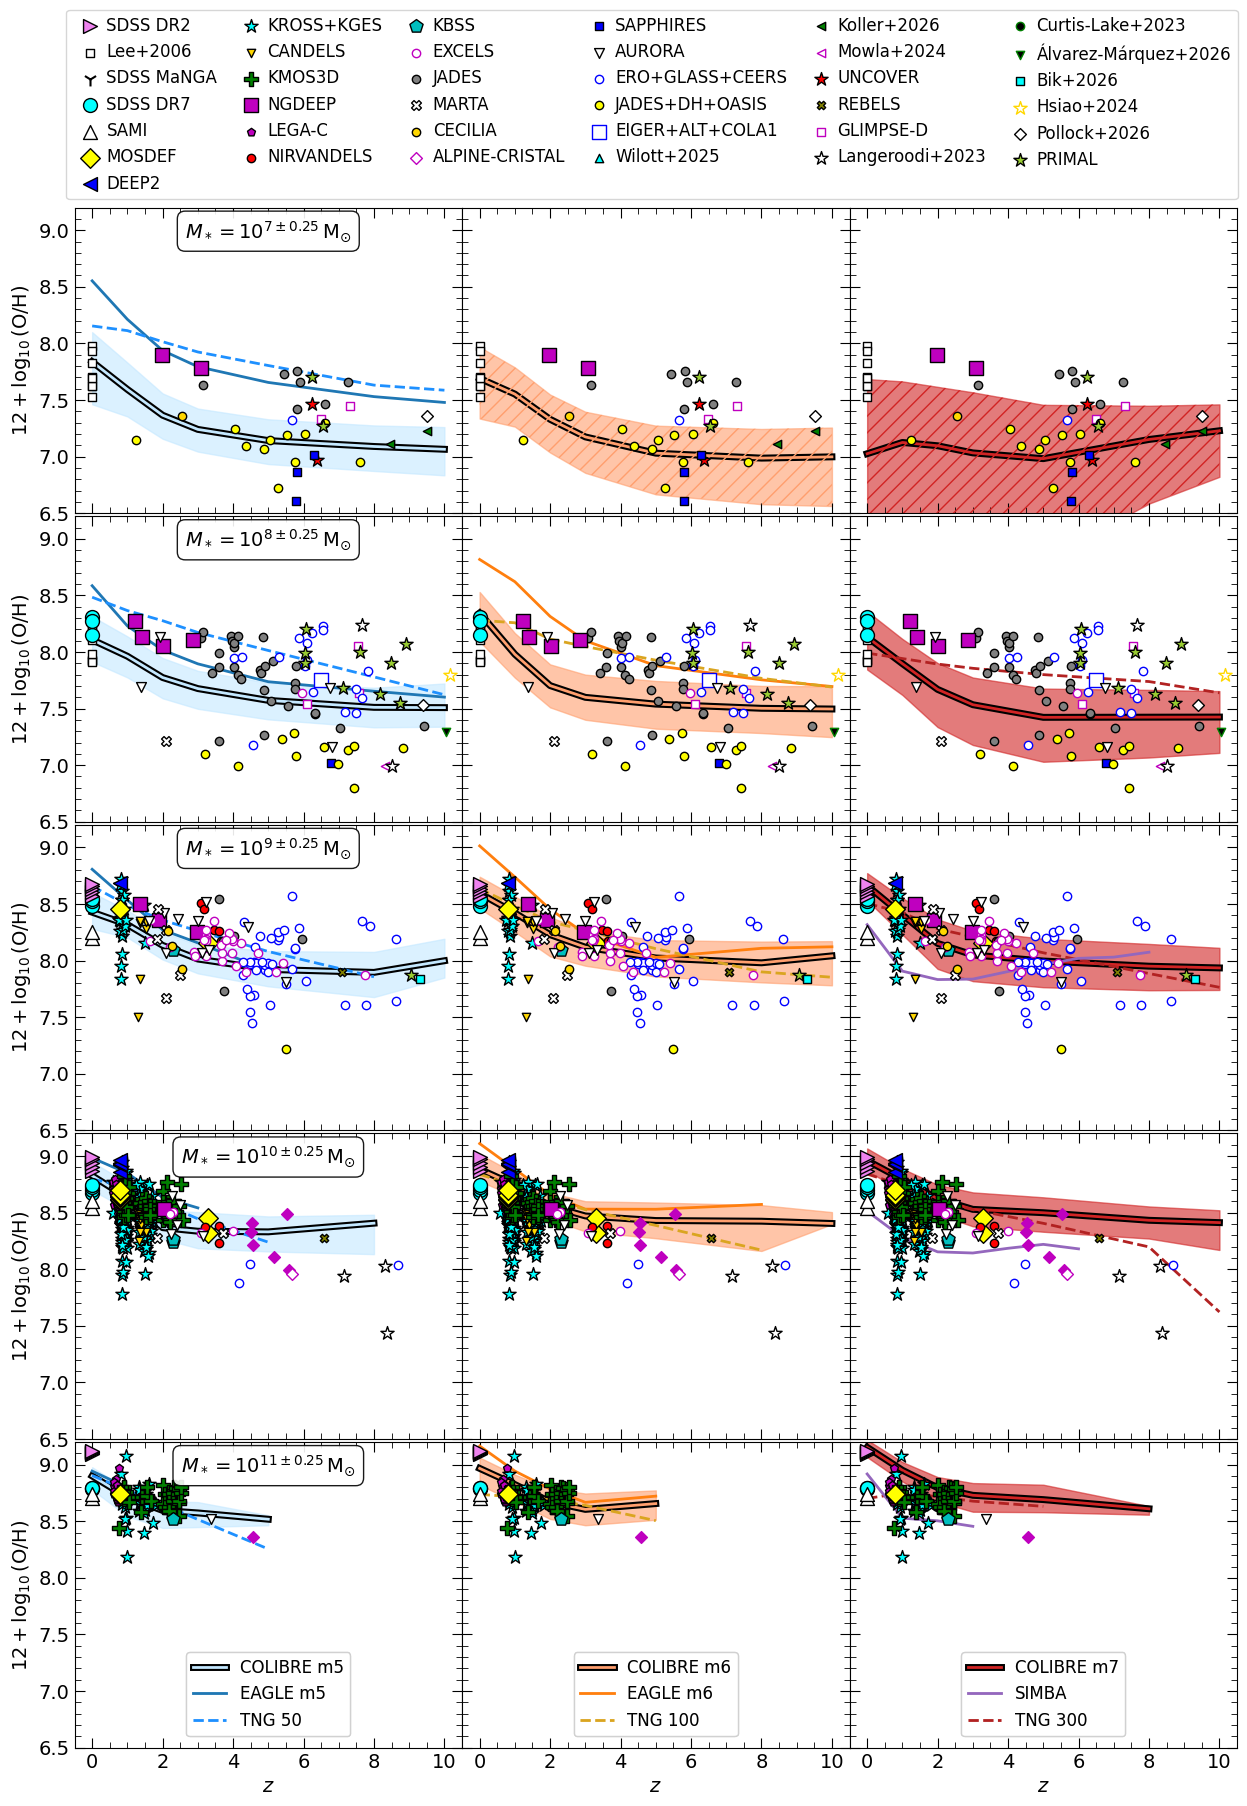

In [8]:
#Figure 6

_tstart = time.time()

snaps = ['0127', '0092', '0076', '0064', '0048', '0026', '0018']
zz = np.array([0, 1, 2, 3, 5, 8, 10])

f, ax = plt.subplots(5, 3, figsize=(15, 20), sharey=True, gridspec_kw = {'wspace':0.0, 'hspace':0.01})

mass_centers=[7,8,9,10,11]
dm = 0.250 #go +/- dm from the mass_centers

for i, logmsel in enumerate(mass_centers):
    for j in range(3):
        plot_obsv_data_z(ax[i][j], zorder=3, logmsel=logmsel, dm=dm)


print('obsv data plotted')

lw = 2

for j in range(0,len(mass_centers)):
    bb = np.load(simpath+f'redshiftplot_colibre_{mass_centers[j]}.npz')
    
    ax[j][0].plot(zz, bb['med_m5'], lw=lw, color=COLIBRE_COLORS[0][1], path_effects=PATH_EFFECTS)
    ax[j][1].plot(zz, bb['med_m6'], lw=lw, color=COLIBRE_COLORS[1][1], path_effects=PATH_EFFECTS)
    ax[j][2].plot(zz, bb['med_m7'], lw=lw, color=COLIBRE_COLORS[2][1], path_effects=PATH_EFFECTS)
        
    ax[j][0].fill_between(zz, bb['p16_m5'], bb['p84_m5'], color=COLIBRE_COLORS[0][1], alpha=0.6, zorder=1)
    if mass_centers[j]==7:
        ax[j][1].fill_between(zz, bb['p16_m6'], bb['p84_m6'], color=COLIBRE_COLORS[1][1], alpha=0.6, zorder=1)
        # hatch overlay since matplotlib does not properly render hatches in PDF
        ax[j][1].fill_between(zz, bb['p16_m6'], bb['p84_m6'], facecolor='none', 
                              edgecolor=COLIBRE_COLORS[1][1], hatch='//', linewidth=0, zorder=2)
    else:
        ax[j][1].fill_between(zz, bb['p16_m6'], bb['p84_m6'], color=COLIBRE_COLORS[1][1], alpha=0.6, zorder=1)
        
    if mass_centers[j]==7:
        ax[j][2].fill_between(zz, bb['p16_m7'], bb['p84_m7'], color=COLIBRE_COLORS[2][1], alpha=0.6, zorder=1)
        # hatch overlay since matplotlib does not properly render hatches in PDF
        ax[j][2].fill_between(zz, bb['p16_m7'], bb['p84_m7'], facecolor='none', 
                              edgecolor=COLIBRE_COLORS[2][1], hatch='//', linewidth=0, zorder=2)
    else:
        ax[j][2].fill_between(zz, bb['p16_m7'], bb['p84_m7'], color=COLIBRE_COLORS[2][1], alpha=0.6, zorder=1)
        
    bb = np.load(simpath+f'redshiftplot_eagle_{mass_centers[j]}.npz')
    ax[j][0].plot(zz, bb['med_m5'], lw=lw, color=defcolcycle[0], ls='solid')
    if mass_centers[j]!=7:
        ax[j][1].plot(zz, bb['med_m6'], lw=lw, color=defcolcycle[1], ls='solid')

    bb = np.load(simpath+f'redshiftplot_tng_{mass_centers[j]}.npz')
    ax[j][0].plot(zz, bb['med_m5'], lw=lw, color='dodgerblue', ls='dashed')
    if mass_centers[j]!=7:
        ax[j][1].plot(zz, bb['med_m6'], lw=lw, color='goldenrod', ls='dashed')
        ax[j][2].plot(zz, bb['med_m7'], lw=lw, color='firebrick', ls='dashed')


label = [r'm5', r'm6', r'm7']


#--------------------------------------------------------------------------------------------
#plot other simulations from Garcia+2025, only using SIMBA
z = [0, 1, 2, 3, 4, 5, 6, 7, 8]
tol = 0.02  #tolerance to catch float precision issues, as stellar mass bins are not "exactly" at 9.95 and 10.05
sims = ['simba'] #

ls= 'solid'
target_bins = [7.75, 7.85, 7.95, 8.05, 8.15, 8.25]
results = {}
for sim in sims:
    mzr_mstar10 = []
    
    for X in range(9):
        mass = globals()[f'{sim}_{X}_mass']
        Z = globals()[f'{sim}_{X}_metallicity']
        
        vals = []
        for tb in target_bins:
            mask = np.abs(mass - tb) < tol
            if np.any(mask):
                vals.append(Z[mask][0])
            else:
                vals.append(np.nan)
        
        mzr_mstar10.append(np.nanmean(vals))
    
    results[sim] = np.array(mzr_mstar10)
ax[1][2].plot(z, results['simba'], c=defcolcycle[4], ls=ls, lw=lw)

target_bins = [8.75, 8.85, 8.95, 9.05, 9.15, 9.25]
results = {}
for sim in sims:
    mzr_mstar10 = []
    
    for X in range(9):
        mass = globals()[f'{sim}_{X}_mass']
        Z = globals()[f'{sim}_{X}_metallicity']
        
        vals = []
        for tb in target_bins:
            mask = np.abs(mass - tb) < tol
            if np.any(mask):
                vals.append(Z[mask][0])
            else:
                vals.append(np.nan)
        
        mzr_mstar10.append(np.nanmean(vals))
    
    results[sim] = np.array(mzr_mstar10)
ax[2][2].plot(z, results['simba'], c=defcolcycle[4], ls=ls, lw=lw)

target_bins = [9.75, 9.85, 9.95, 10.05, 10.15, 10.25]
results = {}
for sim in sims:
    mzr_mstar10 = []
    
    for X in range(9):
        mass = globals()[f'{sim}_{X}_mass']
        Z = globals()[f'{sim}_{X}_metallicity']
        
        vals = []
        for tb in target_bins:
            mask = np.abs(mass - tb) < tol
            if np.any(mask):
                vals.append(Z[mask][0])
            else:
                vals.append(np.nan)
        
        mzr_mstar10.append(np.nanmean(vals))
    
    results[sim] = np.array(mzr_mstar10)
ax[3][2].plot(z, results['simba'], c=defcolcycle[4], ls=ls, lw=lw)

target_bins = [10.75, 10.85, 10.95, 11.05, 11.15, 11.25]
results = {}
for sim in sims:
    mzr_mstar11 = []
    
    for X in range(9):
        mass = globals()[f'{sim}_{X}_mass']
        Z = globals()[f'{sim}_{X}_metallicity']
        
        vals = []
        for tb in target_bins:
            mask = np.abs(mass - tb) < tol
            if np.any(mask):
                vals.append(Z[mask][0])
            else:
                vals.append(np.nan)
        
        mzr_mstar11.append(np.nanmean(vals))
    
    results[sim] = np.array(mzr_mstar11)
ax[4][2].plot(z, results['simba'], c=defcolcycle[4], ls=ls, lw=lw)

for i in range(5):
    for j in range(3):
        if i==4:
            ax[i][j].set_xlabel(r'$z$', fontsize=fontsize)
        if j==0:
            ax[i][j].text(5, 9.1, r'$M_* = 10^{%d \pm %0.2f}\,\rm{M_{\odot}}$'%(mass_centers[i],dm), ha='center', va='top', fontsize=fontsize, bbox=bbox)
        ax[i][j].set_xlim(-0.5, 10.5)
        ax[i][j].set_ylim(6.5, 9.2)
        set_allticks(ax[i][j], fontsize=fontsize)
        if j==0:
            ax[i][j].set_ylabel(r'$12 + \log_{10}(\mathrm{O/H})$', fontsize=fontsize)


# ============================================================
# COMBINED LEGEND (to ensure sequence of labels in the legend is same as Figure3.pdf, use that plot's labels)
# ============================================================

fig_legend = f.legend(unique.values(), unique.keys(), loc='lower center', bbox_to_anchor=(0.51, 0.88),
                      ncol=6, fontsize=fontsize-2, frameon=True, handletextpad=0.01, columnspacing=1.0)

eag_str = ['m5', 'm6']
tng_str = ['50', '100', '300']

for i in range(3):

    ax[4][i].plot(0, 0, lw=lw, color=COLIBRE_COLORS[i][1],path_effects=PATH_EFFECTS)
    ax[4][i].plot(0, 0, lw=lw, color=COLIBRE_COLORS[i][1],path_effects=PATH_EFFECTS)
    ax[4][i].plot(0, 0, lw=lw, color=COLIBRE_COLORS[i][1],path_effects=PATH_EFFECTS)

    ax[4][0].plot(0, 0, lw=lw, color=defcolcycle[0],ls='solid')
    ax[4][0].plot(0, 0, lw=lw, color='dodgerblue',ls='dashed')
    ax[4][1].plot(0, 0, lw=lw, color=defcolcycle[1],ls='solid')
    ax[4][1].plot(0, 0, lw=lw, color='goldenrod',ls='dashed')
    ax[4][2].plot(results['simba']*0, results['simba']*0, c=defcolcycle[4], ls='solid', lw=lw)
    ax[4][2].plot(0, 0, lw=lw, color='firebrick',ls='dashed')

    lines=ax[4][i].get_lines()
    aa=len(lines)-1
    if i<=1:
        legend2 = ax[4][i].legend([lines[k] for k in [aa-2, aa-1, aa]], [r'COLIBRE '+COLIBRE_COLORS[i][0], r'EAGLE '+eag_str[i], r'TNG '+tng_str[i]], 
                             loc='lower center', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.5, 0.01))
    else:
        legend2 = ax[4][i].legend([lines[k] for k in [aa-2, aa-1, aa]], [r'COLIBRE '+COLIBRE_COLORS[i][0], r'SIMBA', r'TNG '+tng_str[i]], 
                             loc='lower center', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.5, 0.01))
    ax[4][i].add_artist(legend2)


#f.savefig('Figure6.pdf', bbox_inches='tight')
f.savefig('../colibre/plot_redshift_evolution_all.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")




Cell took 0.23 s


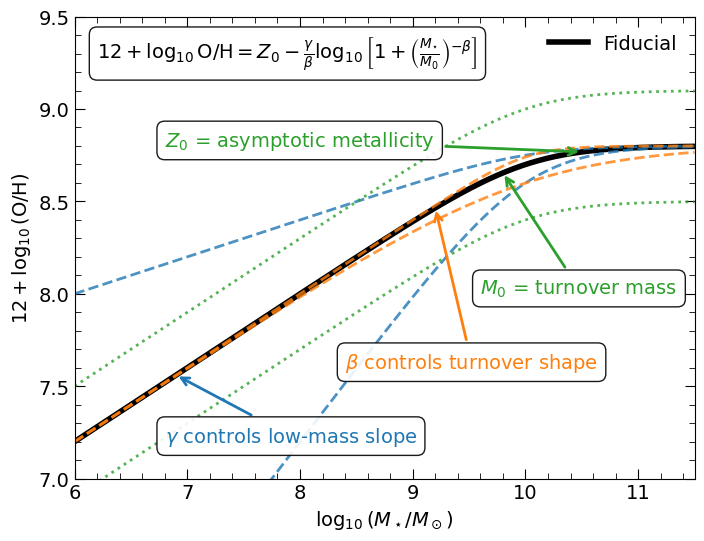

In [10]:
#Figure 7

_tstart = time.time()

# Define BPL function
def mzr(Mstar, gamma, beta, Z0, M0):
    return Z0 - (gamma / beta) * np.log10(1 + (Mstar / M0)**(-beta))

Mstar = np.logspace(6, 11.5, 300)

fontsize = 14

# Fiducial parameters
gamma0 = 0.4
beta0  = 1.2
Z00    = 8.8
M00    = 1e10

fig, ax = plt.subplots(figsize=(8,6))

# --- Fiducial curve ---
y0 = mzr(Mstar, gamma0, beta0, Z00, M00)
ax.plot(np.log10(Mstar), y0, color='k', lw=4, label='Fiducial')

# --- Vary gamma (low-mass slope) ---
for g in [0.2, 0.8]:
    ax.plot(np.log10(Mstar), mzr(Mstar, g, beta0, Z00, M00),
            ls='--', color='C0', alpha=0.8, lw=2)

# --- Vary beta (turnover sharpness) ---
for b in [0.6, 2.0]:
    ax.plot(np.log10(Mstar), mzr(Mstar, gamma0, b, Z00, M00),
            ls='--', color='C1', alpha=0.8,lw=2)

# --- Vary Z0 (vertical shift) ---
for z0 in [8.5, 9.1]:
    ax.plot(np.log10(Mstar), mzr(Mstar, gamma0, beta0, z0, M00),
            ls=':', color='C2', alpha=0.8,lw=2)

ax.annotate(r'$\gamma$ controls low-mass slope',
            xy=(6.9, mzr(10**6.9, gamma0, beta0, Z00, M00)),
            xytext=(6.8, 7.2),
            arrowprops=dict(arrowstyle='->', color='C0', lw=2),
            color='C0',fontsize=fontsize,bbox=bbox)

ax.annotate(r'$\beta$ controls turnover shape',
            xy=(9.2, mzr(10**9.2, gamma0, beta0, Z00, M00)),
            xytext=(8.4, 7.6),
            arrowprops=dict(arrowstyle='->', color='C1', lw=2),
            color='C1',fontsize=fontsize,bbox=bbox)

ax.annotate(r'$Z_0$ = asymptotic metallicity',
            xy=(10.5, mzr(10**10.5, gamma0, beta0, Z00, M00)),
            xytext=(6.8, 8.8),
            arrowprops=dict(arrowstyle='->', color='C2', lw=2),
            color='C2',fontsize=fontsize,bbox=bbox)

ax.annotate(r'$M_0$ = turnover mass',
            xy=(9.8, mzr(10**9.8, gamma0, beta0, Z00, M00)),
            xytext=(9.6, 8.0),
            arrowprops=dict(arrowstyle='->', color='C2',lw=2),
            color='C2',fontsize=fontsize,bbox=bbox)

ax.set_xlabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=fontsize)
ax.set_ylabel(r'$12 + \log_{10}(\mathrm{O/H})$', fontsize=fontsize)

ax.set_xlim(6, 11.5)
ax.set_ylim(7.0, 9.5)

ax.text(6.2, 9.3, r'$12 + \log_{10}\mathrm{O/H} = Z_0 - \frac{\gamma}{\beta} \log_{10}\left[1 + \left(\frac{M_{\star}}{M_0}\right)^{-\beta}\right]$',
       ha='left', va='center', fontsize=fontsize,bbox=bbox)

ax.legend(frameon=False,fontsize=fontsize)
set_allticks(ax)

#fig.savefig('Figure7.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 0.06 s


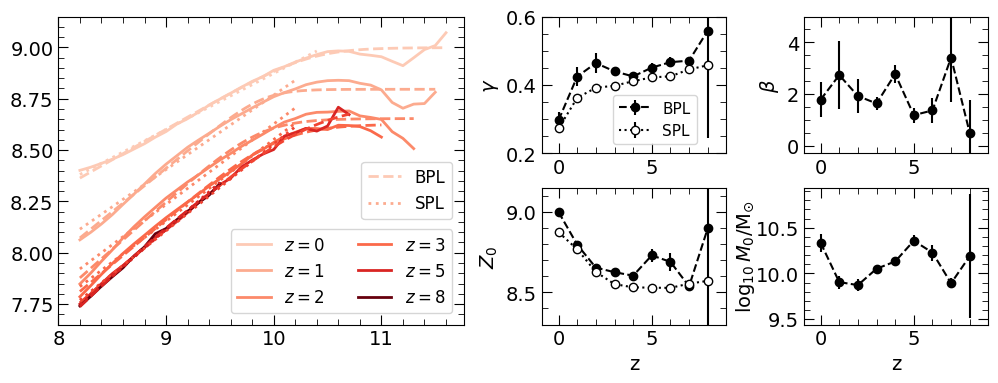

In [69]:
#Figure 8

_tstart = time.time()
snaps = ['0127', '0092', '0076', '0064', '0056', '0048', '0040', '0032', '0026']
zz = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
zvals = [0, 1, 2, 3, 5, 8]

cmap = plt.cm.Reds
colorss = cmap(np.linspace(0.2, 1, len(zz)))


fig = plt.figure(figsize=(12, 4))
gs = GridSpec(2, 3, width_ratios=[2.2, 1, 1], hspace=0.25, wspace=0.3)
fontsize=14
ax_main = fig.add_subplot(gs[:, 0])
# Right 2x2 small panels
ax_gamma = fig.add_subplot(gs[0, 1])
ax_beta  = fig.add_subplot(gs[0, 2])
ax_Z0    = fig.add_subplot(gs[1, 1])
ax_M0    = fig.add_subplot(gs[1, 2])


lw=2
cmodel = 'm6'

ss = np.load(simpath+'fitsave_bpl.npz', allow_pickle=True)
for idx, snap in enumerate(snaps):

    if zz[idx] in zvals:
        ii = zvals.index(zz[idx])
        ax_main.plot(ss['med_aa'][ii], ss['med_bb'][ii], c=colorss[idx], lw=lw, label=r'$z=%d$'%zz[idx])
        ax_main.plot(ss['xfit'][ii], ss['yfit'][ii], ls='--', c=colorss[ii], lw=lw)

ls='dashed'

ax_gamma.errorbar(ss['zz'], ss['gamma'], yerr=ss['gamma_err'], marker='o', color='k',label='BPL',ls=ls)
ax_gamma.set_ylabel(r'$\gamma$',fontsize=fontsize)

ax_beta.errorbar(ss['zz'], ss['beta'], yerr=ss['beta_err'], marker='o', color='k',ls=ls)
ax_beta.set_ylabel(r'$\beta$',fontsize=fontsize)

ax_Z0.errorbar(ss['zz'], ss['Z0'], yerr=ss['Z0_err'], marker='o', color='k',ls=ls)
ax_Z0.set_ylabel(r'$Z_0$',fontsize=fontsize)
ax_Z0.set_xlabel('z',fontsize=fontsize)

ax_M0.errorbar(ss['zz'], ss['logM0'], yerr=ss['logM0_err'], marker='o', color='k',ls=ls)
ax_M0.set_ylabel(r'$\log_{10} M_0/\rm{M_{\odot}}$',fontsize=fontsize, labelpad=-1)
ax_M0.set_xlabel('z',fontsize=fontsize)


ss = np.load(simpath+'fitsave_spl.npz', allow_pickle=True)
for idx, snap in enumerate(snaps):

    if zz[idx] in zvals:
        ii = zvals.index(zz[idx])
        ax_main.plot(ss['xfit'][ii], ss['yfit'][ii], ls='dotted', c=colorss[ii], lw=lw)

ax_gamma.errorbar(ss['zz'], ss['gamma'], yerr=ss['gamma_err'], marker='o', mfc='white', mec='k', ls='dotted', c='k',
                 label='SPL')
ax_gamma.legend(fontsize=fontsize-3, loc='lower right', ncol=1, bbox_to_anchor=(0.88, 0.01))

ax_Z0.errorbar(ss['zz'], ss['Z0'], yerr=ss['Z0_err'], marker='o', mfc='white', mec='k', ls='dotted', c='k')

collections=ax_main.get_lines()
legend2 = ax_main.legend([collections[i] for i in [1,13]], [r'BPL', 
                                                         r'SPL'], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.315))
ax_main.add_artist(legend2)
ax_main.legend(fontsize=fontsize-2, loc='lower right', ncol=2,bbox_to_anchor=(0.99, 0.01))


for ax in [ax_gamma, ax_beta, ax_Z0, ax_M0, ax_main]:
    #ax.tick_params(labelsize=10)
    set_allticks(ax)
    
for ax in [ax_gamma, ax_beta, ax_Z0, ax_M0]:
    ax.set_xlim(-0.9, 9)
    
ax_gamma.set_ylim(0.20, 0.60)
ax_beta.set_ylim(-0.3, 5)
ax_Z0.set_ylim(8.3, 9.15)
ax_main.set_ylim(7.65, 9.15)
ax_main.set_xlim(8,)

#fig.savefig('Figure8.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 0.23 s


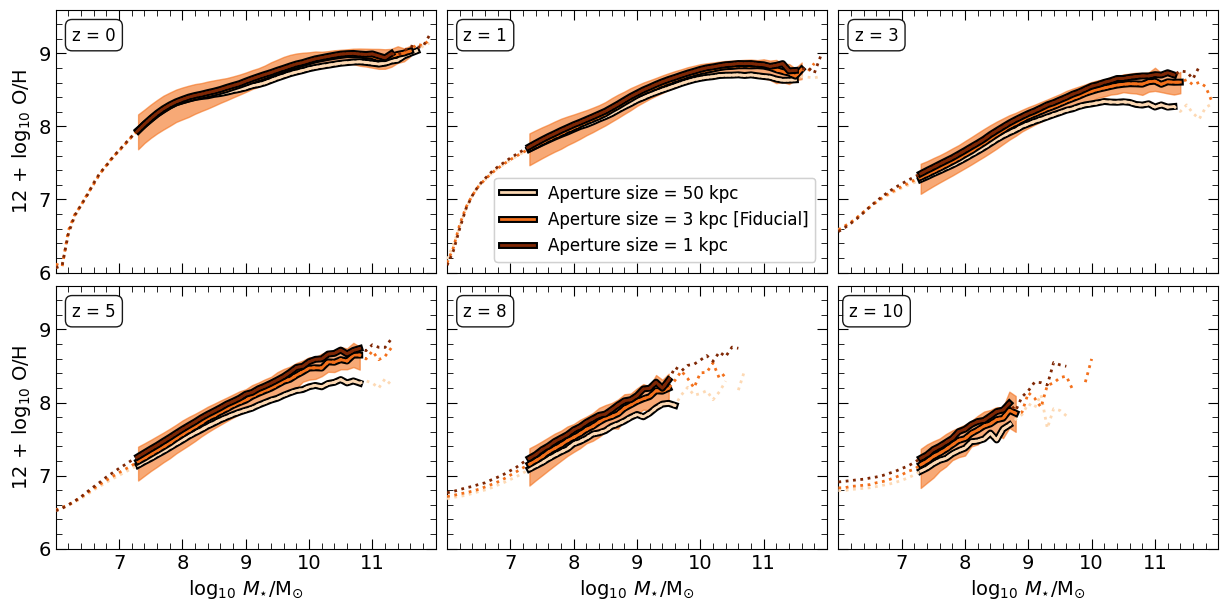

In [50]:
#Figure 9

_tstart = time.time()
f, ax = plt.subplots(2,3, figsize=(15, 7), gridspec_kw = {'wspace':0.03, 'hspace':0.05})
fontsize=14
min_count=20
reslimit_count=10

cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.2, 1, 3))

zorder = 4
snaps = ['0127', '0092', '0064', '0048', '0026', '0018']
zz = [0, 1, 3, 5, 8, 10]
lw=2
model ='m6'
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    bb = np.load(simpath+f'plot_mzr_sims_data_oxygen_50kpc_{model}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[0], zorder=zorder, path_effects=PATH_EFFECTS)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[0], ls='dotted', zorder=zorder)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[0], ls='dotted', zorder=zorder)

    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[1], path_effects=PATH_EFFECTS, zorder=zorder)
    #plot 16/84 percentile scatter
    ax[i][j].fill_between(bb['bin_centers'][mask], bb['p16'][mask], bb['p84'][mask], color=colorss[1], alpha=0.6, zorder=1)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[1], ls='dotted', zorder=zorder)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[1], ls='dotted', zorder=zorder)

    bb = np.load(simpath+f'plot_mzr_sims_data_oxygen_1kpc_{model}_{zz[idx]}.npz')
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[2], zorder=zorder, path_effects=PATH_EFFECTS)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[2], ls='dotted', zorder=zorder)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=colorss[2], ls='dotted', zorder=zorder)
    
    set_allticks(ax[i][j], fontsize=fontsize)
    ax[i][j].set_xticks([7, 8, 9, 10, 11])
    ax[i][j].set_ylim(6, 9.6)
    ax[i][j].set_xlim(6, 12)
    ax[i][j].text(np.log10(4e6), 9.25, 'z = %d'%zz[idx], ha='center', va='center', fontsize=fontsize-2, bbox=bbox)
    if i==1:
        ax[i][j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    else:
        ax[i][j].set_xticklabels([])
    if j==0:
        ax[i][j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[i][j].set_yticklabels([])

ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=colorss[0], label=r'Aperture size = 50 kpc', path_effects=PATH_EFFECTS)
ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=colorss[1], label=r'Aperture size = 3 kpc', path_effects=PATH_EFFECTS)
ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=colorss[2], label=r'Aperture size = 1 kpc', path_effects=PATH_EFFECTS)

lines=ax[0][1].get_lines()
aa=len(lines)-1
legend2 = ax[0][1].legend([lines[i] for i in [aa-2, aa-1, aa]], [r'Aperture size = 50 kpc', 
                                                                 r'Aperture size = 3 kpc [Fiducial]', 
                                                                 r'Aperture size = 1 kpc'],
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.01))
ax[0][1].add_artist(legend2)


#f.savefig('Figure9.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 0.03 s


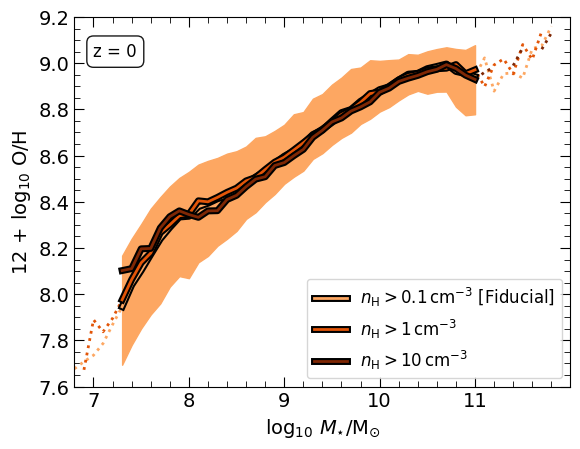

In [85]:
#Figure 10

_tstart = time.time()
f, ax = plt.subplots(1,1)
fontsize=14

min_count = 20
reslimit_count = 10

model = 'm6'

snaps = ['0127']
zz = [0]

cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.4, 1, 3))

idx=0
lw=2

label = [r'$n_{\rm{H}} > 0.1\,\rm{cm^{-3}}$ [Fiducial]', r'$n_{\rm{H}} > 1\,\rm{cm^{-3}}$', 
         r'$n_{\rm{H}} > 10\,\rm{cm^{-3}}$']

def doit(bb, ax, colors=defcolcycle[0], label=r'haha', ls='solid', lw=2, zorder=4, shade=False):
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, c=colors, zorder=zorder, path_effects=PATH_EFFECTS, label=label, ls=ls)
    if shade:
        ax.fill_between(bb['bin_centers'][mask], bb['p16'][mask], bb['p84'][mask], color=colors, zorder=1)
    mask = (bb['counts'] >= min_count)
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    return None

for snap in snaps:
    bb = np.load(simpath+f'nhcuts_nhm1_{snap}.npz')
    doit(bb, ax, colors=colorss[0], label=label[0], lw=lw, shade=True)
    bb = np.load(simpath+f'nhcuts_nhm0_{snap}.npz')
    doit(bb, ax, colors=colorss[1], label=label[1], lw=lw)
    bb = np.load(simpath+f'nhcuts_nhp1_{snap}.npz')
    doit(bb, ax, colors=colorss[2], label=label[2], lw=lw)
        
set_allticks(ax, fontsize=fontsize)
ax.set_xticks([7, 8, 9, 10, 11])
ax.set_ylim(7.6, 9.2)
ax.set_xlim(6.8, 12)
ax.text(np.log10(1e7), 9.05, 'z = %d'%zz[idx], ha='left', va='center', fontsize=fontsize-2,bbox=bbox)
ax.set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
ax.set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)

ax.legend(loc='lower right', fontsize=fontsize-2)
#f.savefig('Figure10.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")




Cell took 0.03 s


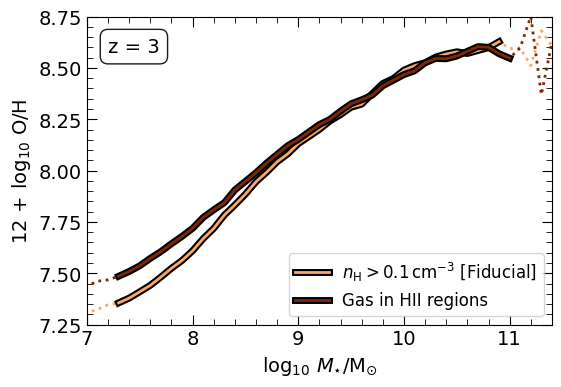

In [21]:
#Figure 11

_tstart = time.time()
f, ax = plt.subplots(1,1,figsize=(6,4))
fontsize=14

min_count = 20
reslimit_count = 10

model = 'm6'

snaps = ['0064']
zz = [3]

cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.4, 1, 2))

idx=0
lw=2

label = [r'$n_{\rm{H}} > 0.1\,\rm{cm^{-3}}$ [Fiducial]', r'Gas in HII regions']

def doit(bb, ax, colors=defcolcycle[0], label=r'haha', ls='solid', lw=2, zorder=4):
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, c=colors, zorder=zorder, path_effects=PATH_EFFECTS, label=label, ls=ls)
    mask = (bb['counts'] >= min_count)
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    return None

for idx, snap in enumerate(snaps):

    try:
        bb = np.load(simpath+f'hiiregionendtime_orig_{snap}.npz')
        doit(bb, ax, colors=colorss[0], label=label[0], lw=lw)
        bb = np.load(simpath+f'hiiregionendtime_new_{snap}.npz')
        doit(bb, ax, colors=colorss[1], label=label[1], lw=lw)
    except:
        print('File not found')
        
    set_allticks(ax, fontsize=fontsize)
    ax.set_xticks([7, 8, 9, 10, 11])
    ax.set_ylim(7.25, 8.75)
    ax.set_xlim(7, 11.4)
    ax.text(7.2, 8.65, 'z = %d'%zz[idx], ha='left', va='top', fontsize=fontsize, bbox=bbox)
    ax.set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    ax.set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)

ax.legend(loc='lower right', fontsize=fontsize-2)
#f.savefig('Figure11.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")




Cell took 0.06 s


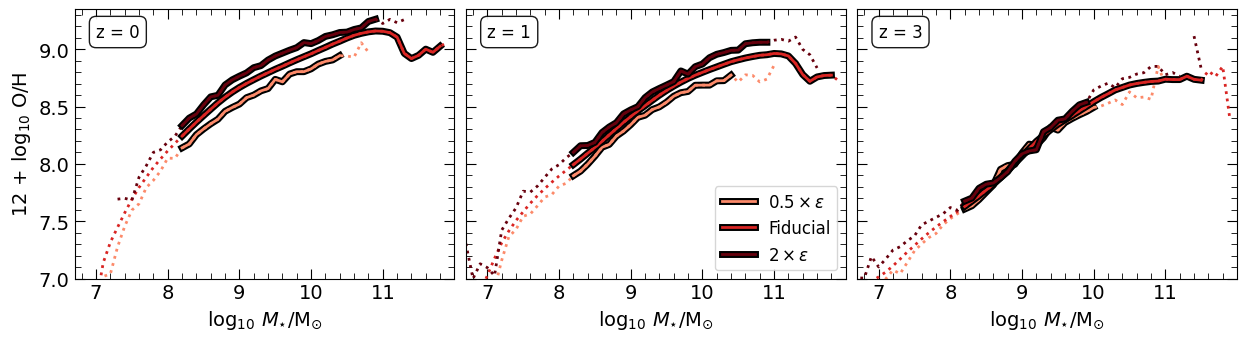

In [57]:
#Figure 12

_tstart = time.time()
f, ax = plt.subplots(1,3,figsize=(15,3.5), gridspec_kw = {'wspace':0.03, 'hspace':0.0})
fontsize=14

min_count = 20
reslimit_count = 10

model = 'm7'

snaps = ['0127', '0092', '0064']
zz = [0, 1, 3]

cmap = plt.cm.Reds
colorss = cmap(np.linspace(0.4, 1, 3))

idx=0
lw=2

modvar0 = 'Thermal_0p5SFE'
modvar1 = 'Thermal_2p0SFE'

label = [r'$0.5\times \epsilon$', r'Fiducial', r'$2\times \epsilon$']

def doit(bb, ax, colors=defcolcycle[0], label=r'haha', ls='solid', lw=2, zorder=4, agn=False):
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, c=colors, zorder=zorder, path_effects=PATH_EFFECTS, label=label, ls=ls)
    mask = (bb['counts'] >= min_count)
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, color=colors, ls='dotted', zorder=zorder)
    return None

for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    bb = np.load(simpath+f'variations_{modvar0}_{snap}.npz')
    doit(bb, ax[j], colors=colorss[0], label=label[0], lw=lw)
    
    model='m7'
    bb = np.load(simpath+f'/plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    doit(bb, ax[j], colors=colorss[1], label=label[1], lw=lw)

    bb = np.load(simpath+f'variations_{modvar1}_{snap}.npz')
    doit(bb, ax[j], colors=colorss[2], label=label[2], lw=lw)
        
    set_allticks(ax[j], fontsize=fontsize)
    ax[j].set_xticks([7, 8, 9, 10, 11])
    ax[j].set_ylim(7, 9.35)
    ax[j].set_xlim(6.7, 12)
    ax[j].text(np.log10(1e7), 9.15, 'z = %d'%zz[idx], ha='left', va='center', fontsize=fontsize-2, bbox=bbox)
    ax[j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    if j==0:
        ax[j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[j].set_yticklabels([])

ax[1].legend(loc='lower right', fontsize=fontsize-2)
#f.savefig('Figure12.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")




Cell took 0.05 s


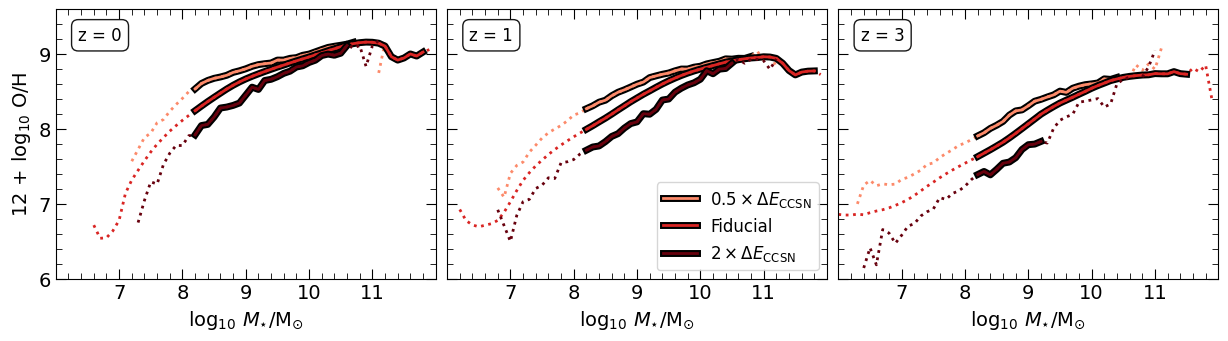

In [59]:
#Figure 13

_tstart = time.time()
f, ax = plt.subplots(1,3,figsize=(15,3.5), gridspec_kw = {'wspace':0.03, 'hspace':0.0})
fontsize=14

min_count = 20
reslimit_count = 10

model = 'm7'

snaps = ['0127', '0092', '0064']
zz = [0, 1, 3]

cmap = plt.cm.Reds
colorss = cmap(np.linspace(0.4, 1, 3))

idx=0
lw=2

modvar0 = 'Thermal_0p5SNenergy'
modvar1 = 'Thermal_2p0SNenergy'

label_ccsn = [r'$0.5\times \Delta E_{\rm{CCSN}}$', r'Fiducial', 
            r'$2\times \Delta E_{\rm{CCSN}}$']

label = label_ccsn
title = r'Variations in supernova feedback'
fname = 'plot_modelvariations_ccsn.pdf'
    
def doit(bb, ax, colors=defcolcycle[0], label=r'haha', ls='solid', lw=2, zorder=4):
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, c=colors, zorder=zorder, path_effects=PATH_EFFECTS, label=label, ls=ls)
    mask = (bb['counts'] >= min_count)
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, color=colors, ls='dotted', zorder=zorder)
    return None

for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    bb = np.load(simpath+f'variations_{modvar0}_{snap}.npz')
    doit(bb, ax[j], colors=colorss[0], label=label[0], lw=lw)
    
    model='m7'
    bb = np.load(simpath+f'/plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    doit(bb, ax[j], colors=colorss[1], label=label[1], lw=lw)

    bb = np.load(simpath+f'variations_{modvar1}_{snap}.npz')
    doit(bb, ax[j], colors=colorss[2], label=label[2], lw=lw)
        
    set_allticks(ax[j], fontsize=fontsize)
    ax[j].set_xticks([7, 8, 9, 10, 11])
    ax[j].set_ylim(6, 9.6)
    ax[j].set_xlim(6, 12)
    ax[j].text(np.log10(5e6), 9.25, 'z = %d'%zz[idx], ha='center', va='center', fontsize=fontsize-2, bbox=bbox)
    ax[j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    if j==0:
        ax[j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[j].set_yticklabels([])

ax[1].legend(loc='lower right', fontsize=fontsize-2)
#f.savefig('Figure13.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")




Cell took 0.38 s


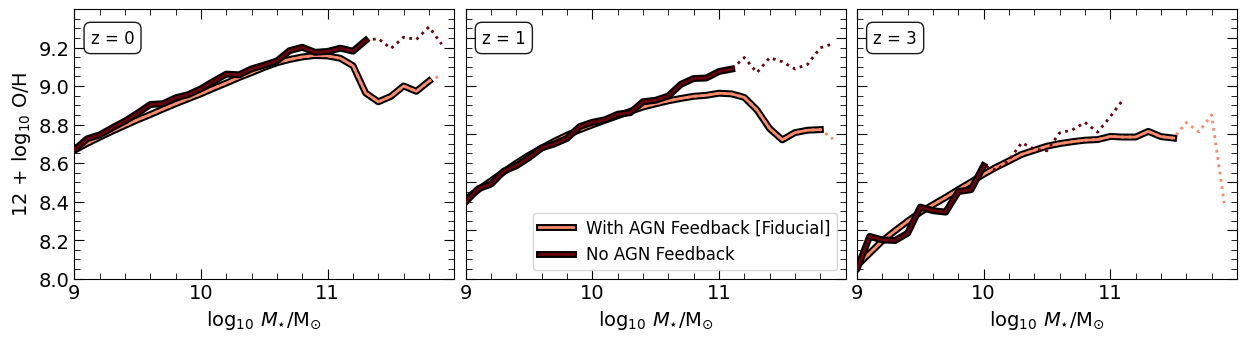

In [19]:
#Figure 14

_tstart = time.time()
f, ax = plt.subplots(1,3,figsize=(15,3.5), gridspec_kw = {'wspace':0.03, 'hspace':0.00})
fontsize=14

min_count = 20
reslimit_count = 10

model = 'm7'

snaps = ['0127', '0092', '0064']
zz = [0, 1, 3]

cmap = plt.cm.Reds
colorss = cmap(np.linspace(0.4, 1, 2))

idx=0
lw=2
aperture='3kpc'

label = [r'With AGN Feedback [Fiducial]', 
             r'No AGN Feedback']

def doit(bb, ax, colors=defcolcycle[0], label=r'haha', ls='solid', lw=2, zorder=4):
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, c=colors, zorder=zorder, path_effects=PATH_EFFECTS, label=label, ls=ls)
    mask = (bb['counts'] >= min_count)
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, color=colors, ls='dotted', zorder=zorder)
    return None

for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    model='m7'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    doit(bb, ax[j], colors=colorss[0], label=label[0], lw=lw)

    bb = np.load(simpath+f'noagn_{snap}.npz')
    doit(bb, ax[j], colors=colorss[1], label=label[1], lw=lw)
        
    set_allticks(ax[j], fontsize=fontsize)
    ax[j].set_xticks([7, 8, 9, 10, 11])
    ax[j].set_ylim(8, 9.4)
    ax[j].set_xlim(9, 12)
    ax[j].text(np.log10(2e9), 9.25, 'z = %d'%zz[idx], ha='center', va='center', fontsize=fontsize-2, bbox=bbox)
    ax[j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    if j==0:
        ax[j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
        ax[j].set_yticks([8, 8.2, 8.4, 8.6, 8.8, 9.0, 9.2])
        ax[j].set_yticklabels(['8.0', '8.2', '8.4', '8.6', '8.8', '9.0', '9.2'])
    else:
        ax[j].set_yticklabels([])

ax[1].legend(loc='lower right', fontsize=fontsize-2)
#f.savefig('Figure14.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")




Cell took 0.05 s


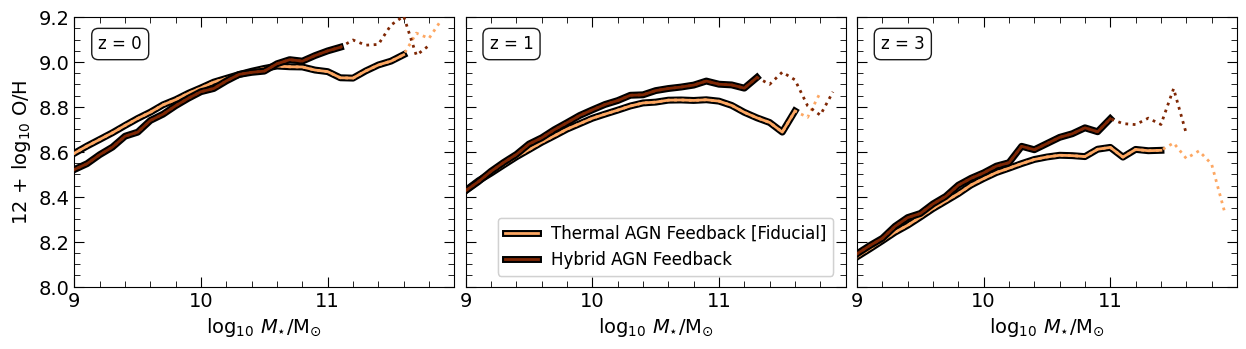

In [72]:
#Figure 15

_tstart = time.time()
f, ax = plt.subplots(1,3, figsize=(15, 3.5), gridspec_kw = {'wspace':0.03, 'hspace':0.0})

fontsize=14
min_count=20
reslimit_count=10

cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.4, 1, 2))

snaps = ['0127', '0092', '0064']
zz = [0, 1, 3]

def doit(bb, ax, colors=defcolcycle[0], label=r'haha', ls='solid', lw=2, zorder=4):
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, c=colors, zorder=zorder, path_effects=PATH_EFFECTS, label=label, ls=ls)
    mask = (bb['counts'] >= min_count)
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, ls='dotted', c=colors)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax.plot(bb['bin_centers'][mask], bb['medians'][mask], lw=lw, color=colors, ls='dotted', zorder=zorder)
    return None

lw=2
model='m6'
for idx, snap in enumerate(snaps):

    i, j = divmod(idx,3)
    
    model='m6'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    doit(bb, ax[j], colors=colorss[0], lw=lw)

    bb = np.load(simpath+f'hybridagn_{snap}.npz')
    doit(bb, ax[j], colors=colorss[1], lw=lw)

    set_allticks(ax[j], fontsize=fontsize)
    ax[j].set_xticks([7, 8, 9, 10, 11])
    ax[j].set_ylim(8, 9.2)
    ax[j].set_xlim(9, 12)
    ax[j].text(np.log10(2.3e9), 9.08, 'z = %d'%zz[idx], ha='center', va='center', fontsize=fontsize-2, bbox=bbox)
    ax[j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    if j==0:
        ax[j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[j].set_yticklabels([])

ax[1].plot(0, 0, lw=lw, color=colorss[0], label=r'Thermal AGN Feedback',path_effects=PATH_EFFECTS)
ax[1].plot(0, 0, lw=lw, color=colorss[1], label=r'Hybrid AGN Feedback',path_effects=PATH_EFFECTS)

lines=ax[1].get_lines()
aa=len(lines)-1
legend2 = ax[1].legend([lines[i] for i in [aa-1, aa]], [r'Thermal AGN Feedback [Fiducial]',
                                                           r'Hybrid AGN Feedback'], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.99, 0.01))
ax[1].add_artist(legend2)

#f.savefig('Figure15.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 0.03 s


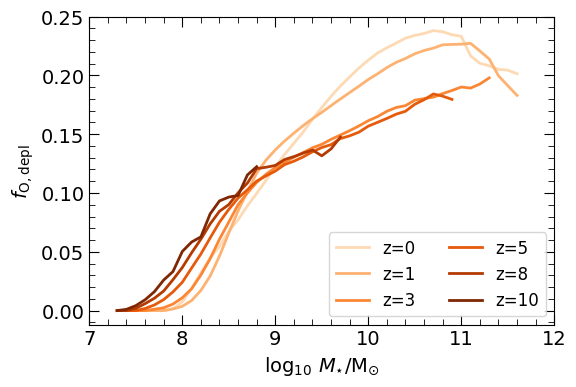

In [7]:
#Figure 16

_tstart = time.time()
f, ax = plt.subplots(1,1,figsize=(6,4))
fontsize=14
min_count=20
reslimit_count=10

cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.2, 1, 6))

snaps = ['0127', '0092', '0064', '0048', '0026', '0018']
zz = [0, 1, 3, 5, 8, 10]
lw=2
zorder = 4
for idx, snap in enumerate(snaps):

    bb = np.load(simpath+f'dustdepl_frac_{snaps[idx]}.npz')
    ax.plot(bb['bin_centers'], bb['medians'], lw=2, c=colorss[idx], zorder=zorder, label=r'z=%d'%zz[idx])

set_allticks(ax, fontsize=fontsize)
ax.set_xlim(7, 12)
ax.legend(fontsize=fontsize-2, loc='lower right', ncol=2)
ax.set_ylabel(r'$f_{\rm{O,depl}}$', fontsize=fontsize)
ax.set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)

#f.savefig('Figure16.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Cell took 0.02 s


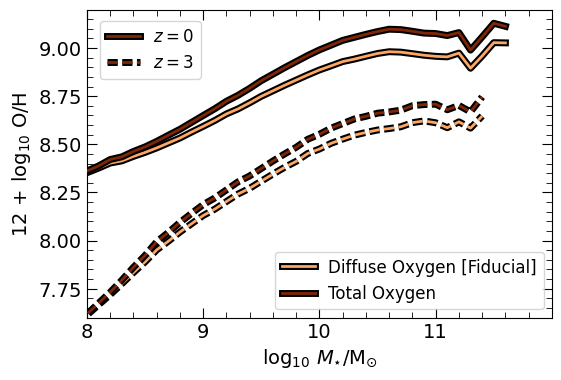

In [52]:
#Figure 17

_tstart = time.time()
f, ax = plt.subplots(1,1,figsize=(6,4))
fontsize=14

snaps = ['0127', '0092', '0064', '0048', '0026', '0018']
zz = [0, 1, 3, 5, 8, 10]
cmap = plt.cm.Oranges
colorss = cmap(np.linspace(0.4, 1, 2))

idx=0
bb=np.load(simpath+f'dustdepl_mzr_{snaps[idx]}.npz')
ax.plot(bb['bin_centers'], bb['medians'], lw=2, c=colorss[0], zorder=zorder, path_effects=PATH_EFFECTS, label=r'Diffuse Oxygen [Fiducial]')
ax.plot(bb['bin_centers2'], bb['medians2'], lw=2, c=colorss[1], zorder=zorder, path_effects=PATH_EFFECTS, label=r'Total Oxygen')

idx=2
bb=np.load(simpath+f'dustdepl_mzr_{snaps[idx]}.npz')
ax.plot(bb['bin_centers'], bb['medians'], lw=2, c=colorss[0], zorder=zorder, path_effects=PATH_EFFECTS, ls='dashed')
ax.plot(bb['bin_centers2'], bb['medians2'], lw=2, c=colorss[1], zorder=zorder, path_effects=PATH_EFFECTS, ls='dashed')

set_allticks(ax, fontsize=fontsize)
ax.set_ylim(7.6, 9.2)
ax.set_xlim(8, 12)
ax.set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
ax.set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
ax.set_xticks([8, 9, 10, 11])

lines=ax.get_lines()
aa=len(lines)-1
legend2 = ax.legend([lines[i] for i in [aa-2, aa]], [r'$z=0$', r'$z=3$'],
                     loc='upper left', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.01, 0.99))
ax.add_artist(legend2)
ax.legend(fontsize=fontsize-2, loc='lower right')

#f.savefig('Figure17.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")

